In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")

np.random.seed(123)

n, p = 20, 50

X1 = np.random.normal(0, 1, (n, p))
X2 = np.random.normal(3, 1, (n, p))
X3 = np.random.normal(6, 1, (n, p))

X = np.vstack((X1, X2, X3))
labels_true = np.array([0]*n + [1]*n + [2]*n)

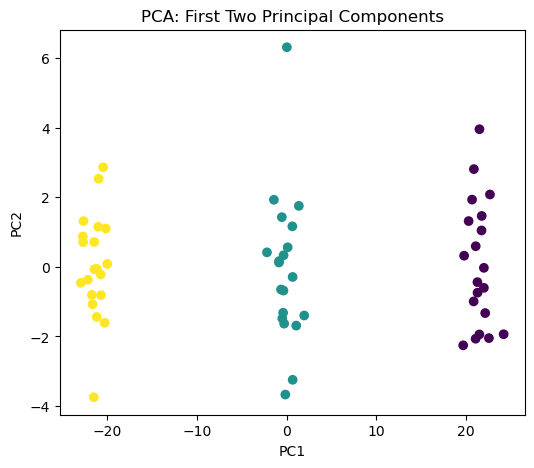

In [33]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_true, cmap='viridis')
plt.title('PCA: First Two Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [35]:
kmeans3 = KMeans(n_clusters=3, random_state=123)
labels_k3 = kmeans3.fit_predict(X)

pd.crosstab(labels_true, labels_k3, rownames=['True'], colnames=['K-means'])

K-means,0,1,2
True,,,
0,0,20,0
1,0,0,20
2,20,0,0


In [37]:
kmeans2 = KMeans(n_clusters=2, random_state=123)
labels_k2 = kmeans2.fit_predict(X)
pd.crosstab(labels_true, labels_k2)

col_0,0,1
row_0,,
0,0,20
1,0,20
2,20,0


In [39]:
kmeans4 = KMeans(n_clusters=4, random_state=123)
labels_k4 = kmeans4.fit_predict(X)
pd.crosstab(labels_true, labels_k4)

col_0,0,1,2,3
row_0,,,,
0,0,20,0,0
1,0,0,8,12
2,20,0,0,0


In [41]:
kmeans_pca = KMeans(n_clusters=3, random_state=123)
labels_pca = kmeans_pca.fit_predict(X_pca)
pd.crosstab(labels_true, labels_pca)

col_0,0,1,2
row_0,,,
0,0,20,0
1,0,0,20
2,20,0,0


In [43]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans_scaled = KMeans(n_clusters=3, random_state=123)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)
pd.crosstab(labels_true, labels_scaled)

col_0,0,1,2
row_0,,,
0,0,20,0
1,0,0,20
2,20,0,0
